# **DSP PBL PROJECT**

In [ ]:
# --- CELL 1: Install (Colab only) ---
# Run this cell in Colab. Locally: pip install scikit-learn pandas matplotlib seaborn joblib gradio
!pip install -q scikit-learn pandas matplotlib seaborn joblib gradio


In [ ]:
# --- CELL 2: Imports & config ---
import re, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import gradio as gr

# CONFIG - change DATA_PATH if needed
DATA_PATH = Path("/content/WELFake_Dataset.csv")   # typical Colab upload path
MODEL_DIR = Path("/content/models_fixed")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_MODE = True        # True -> do stratified sampling from whole dataset (recommended)
SAMPLE_SIZE = 20000      # number of rows sampled (stratified)
TEST_SIZE = 0.2

TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.95
NGRAM_RANGE = (1,2)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [ ]:
# --- CELL 3: Robust text cleaning & helpers ---
def clean_text_keep_punct(s: str) -> str:
    """Moderate cleaning: lowercase, remove URLs/emails, keep common punctuation .,?! to preserve sentence info."""
    if s is None:
        return ""
    s = str(s)
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\S+@\S+", " ", s)
    # keep .,?! and alphanumerics and spaces
    s = re.sub(r"[^a-z0-9\.\,\?\!\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def detect_text_label_columns(sample_df: pd.DataFrame):
    """Return (text_columns_list, label_col_name). Prints detection result."""
    sample_cols = list(sample_df.columns)
    # find text-like columns
    text_cols = [c for c in sample_cols if any(k in c.lower() for k in ("title","text","article","content","body","news"))]
    label_cols = [c for c in sample_cols if any(k in c.lower() for k in ("label","target","truth","class","is_fake","fake"))]
    # choose
    if "title" in sample_df.columns and "text" in sample_df.columns:
        text_use = ["title","text"]
    elif len(text_cols) >= 1:
        text_use = text_cols[:2]  # prefer first two if available
    else:
        # fallback to first object column
        obj_cols = sample_df.select_dtypes(include=['object']).columns.tolist()
        text_use = [obj_cols[0]] if obj_cols else [sample_cols[0]]
    label_use = label_cols[0] if label_cols else sample_cols[-1]
    print("Detected text columns:", text_use, "Label column:", label_use)
    return text_use, label_use

def map_label_safe(series: pd.Series) -> pd.Series:
    """Map various label formats reliably to 0 (real) / 1 (fake)."""
    s = series.astype(str).str.lower().str.strip()
    unique_vals = s.unique().tolist()
    print("Unique raw label samples (up to 20):", unique_vals[:20])
    # if textual contains 'fake' or 'real'
    if any('fake' in v for v in unique_vals) or any('real' in v for v in unique_vals):
        return s.map(lambda x: 1 if 'fake' in x else 0).astype(int)
    # if purely numeric-like 0/1
    try:
        cast = s.astype(int)
        # assume 1 -> fake (if majority 1s and user expects fake)
        return cast.astype(int)
    except:
        # fallback to categorical codes (still consistent)
        print("Warning: using categorical codes for labels (fallback).")
        return pd.Categorical(s).codes


In [ ]:
# --- CELL 4: Load full CSV, show diagnostics, do stratified sampling ---
start = time.time()
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Upload your dataset to {DATA_PATH} or change DATA_PATH variable.")
print("Reading header to detect columns...")
head = pd.read_csv(DATA_PATH, nrows=5)
text_cols, label_col = detect_text_label_columns(head)

print("Loading entire CSV (to allow correct stratified sampling)...")
df_all = pd.read_csv(DATA_PATH, usecols= [c for c in set([*text_cols, label_col]) if c in pd.read_csv(DATA_PATH, nrows=0).columns])
# combine text columns safely (if they exist)
for c in text_cols:
    if c not in df_all.columns:
        df_all[c] = ""
df_all['full_text_raw'] = df_all[text_cols].fillna("").agg(" ".join, axis=1)
# drop empty text rows
df_all = df_all[df_all['full_text_raw'].str.strip() != ""].dropna(subset=[label_col]).reset_index(drop=True)
print("Total rows available after cleanup:", len(df_all))
# map labels safely
df_all['label_mapped'] = map_label_safe(df_all[label_col])
print("Label distribution (mapped):")
print(df_all['label_mapped'].value_counts(normalize=True))
# stratified sampling to get representative sample for training (if requested)
if SAMPLE_MODE:
    print(f"Performing stratified sample of {SAMPLE_SIZE} rows (preserving label balance)...")
    # if dataset smaller than sample size -> use all
    if len(df_all) <= SAMPLE_SIZE:
        df = df_all.copy()
    else:
        # stratified sample: sample proportionally from each label group
        df = df_all.groupby('label_mapped', group_keys=False).apply(lambda x: x.sample(frac=min(1, SAMPLE_SIZE/len(df_all)), random_state=RANDOM_STATE))
        # if we undershot due to rounding, further sample randomly to exact SAMPLE_SIZE
        if len(df) > SAMPLE_SIZE:
            df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
        elif len(df) < SAMPLE_SIZE:
            # sample remaining from df_all
            extra = df_all.drop(df.index).sample(n=(SAMPLE_SIZE - len(df)), random_state=RANDOM_STATE)
            df = pd.concat([df, extra], ignore_index=True)
    df = df.reset_index(drop=True)
else:
    df = df_all.copy()
print("Final sample shape used for training/eval:", df.shape)
# apply moderate cleaning
df['full_text'] = df['full_text_raw'].map(clean_text_keep_punct)
# filter very short texts
df = df[df['full_text'].str.len() > 20].reset_index(drop=True)
print("After removing very short items:", df.shape)
print("Sample label counts (after cleaning):")
print(df['label_mapped'].value_counts())
print("Load + sample time: %.1fs" % (time.time()-start))


Reading header to detect columns...
Detected text columns: ['title', 'text'] Label column: label
Loading entire CSV (to allow correct stratified sampling)...
Total rows available after cleanup: 72134
Unique raw label samples (up to 20): ['1', '0']
Label distribution (mapped):
label_mapped
1    0.514404
0    0.485596
Name: proportion, dtype: float64
Performing stratified sample of 20000 rows (preserving label balance)...
Final sample shape used for training/eval: (20000, 5)


/tmp/ipython-input-3580556491.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_all.groupby('label_mapped', group_keys=False).apply(lambda x: x.sample(frac=min(1, SAMPLE_SIZE/len(df_all)), random_state=RANDOM_STATE))


After removing very short items: (19988, 6)
Sample label counts (after cleaning):
label_mapped
1    10276
0     9712
Name: count, dtype: int64
Load + sample time: 15.0s


In [ ]:
# --- CELL 5: Train/Test split (stratified) & TF-IDF vectorization ---
X = df['full_text']
y = df['label_mapped']
# stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train size:", len(X_train), "Test size:", len(X_test))

# TF-IDF with less aggressive filtering
tfidf = TfidfVectorizer(stop_words='english', min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF, ngram_range=NGRAM_RANGE)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
print("TF-IDF shapes:", X_train_vec.shape, X_test_vec.shape)

# Save vectorizer for later
joblib.dump(tfidf, MODEL_DIR/"tfidf.joblib")


Train size: 15990 Test size: 3998
TF-IDF shapes: (15990, 598766) (3998, 598766)


['/content/models_fixed/tfidf.joblib']

In [ ]:
# --- CELL 6: Train classical models (LogReg, NB, SVM) with balanced settings ---
# Logistic Regression (balanced)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)

# SVM (LinearSVC) with balanced class weight
svm = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)

# Save models
joblib.dump(lr, MODEL_DIR/"logreg.joblib")
joblib.dump(nb, MODEL_DIR/"nb.joblib")
joblib.dump(svm, MODEL_DIR/"svm.joblib")
print("Models trained and saved to", MODEL_DIR)


Models trained and saved to /content/models_fixed



Metrics table:
                     accuracy  precision  recall      f1
model                                                  
LogisticRegression    0.9275     0.9233  0.9367  0.9300
NaiveBayes            0.8817     0.9086  0.8560  0.8815
SVM                   0.9482     0.9438  0.9562  0.9500


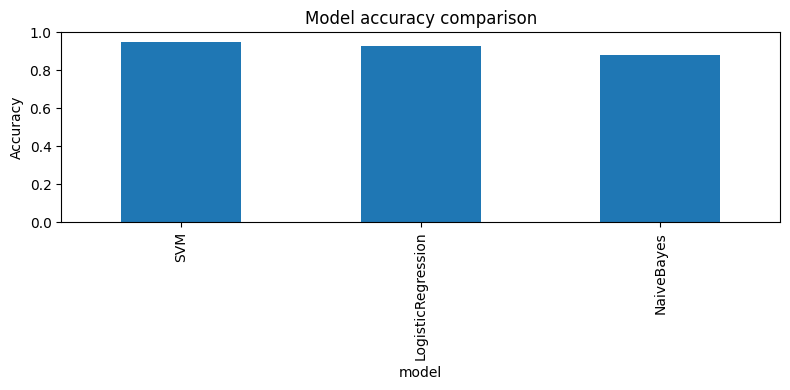

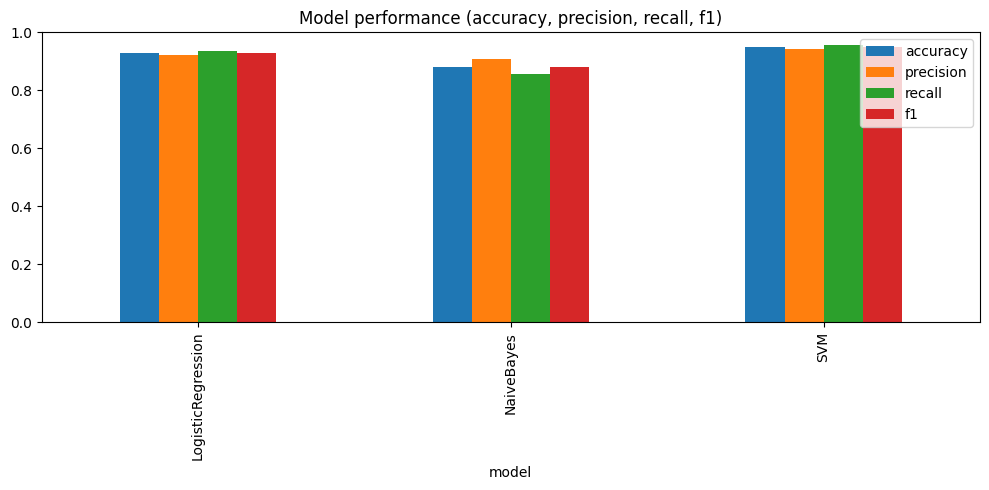


=== LogisticRegression ===
              precision    recall  f1-score   support

           0     0.9320    0.9177    0.9248      1943
           1     0.9233    0.9367    0.9300      2055

    accuracy                         0.9275      3998
   macro avg     0.9277    0.9272    0.9274      3998
weighted avg     0.9275    0.9275    0.9274      3998



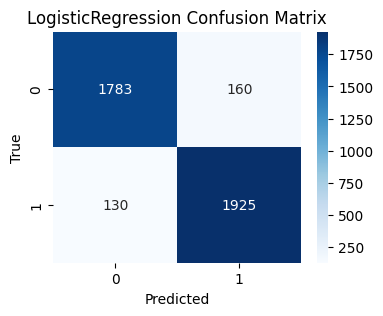


=== NaiveBayes ===
              precision    recall  f1-score   support

           0     0.8565    0.9089    0.8819      1943
           1     0.9086    0.8560    0.8815      2055

    accuracy                         0.8817      3998
   macro avg     0.8825    0.8824    0.8817      3998
weighted avg     0.8832    0.8817    0.8817      3998



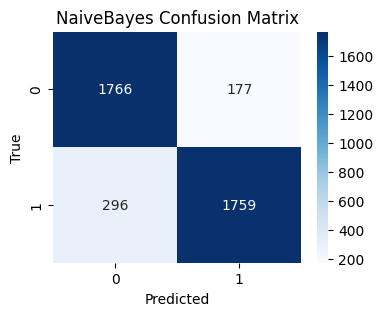


=== SVM ===
              precision    recall  f1-score   support

           0     0.9530    0.9398    0.9464      1943
           1     0.9438    0.9562    0.9500      2055

    accuracy                         0.9482      3998
   macro avg     0.9484    0.9480    0.9482      3998
weighted avg     0.9483    0.9482    0.9482      3998



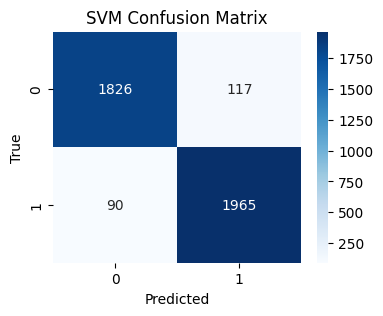

In [ ]:
# --- CELL 7: Evaluation diagnostics & visuals (metrics table, confusion matrices, reports) ---
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {"accuracy":acc, "precision":prec, "recall":rec, "f1":f1}

models_preds = {"LogisticRegression": lr_pred, "NaiveBayes": nb_pred, "SVM": svm_pred}
metrics = {}
for name, pred in models_preds.items():
    metrics[name] = compute_metrics(y_test, pred)

metrics_df = pd.DataFrame(metrics).T[['accuracy','precision','recall','f1']]
metrics_df.index.name = "model"
print("\nMetrics table:\n", metrics_df.round(4))

# Plots
plt.figure(figsize=(8,4))
metrics_df['accuracy'].sort_values(ascending=False).plot(kind='bar', title='Model accuracy comparison')
plt.ylabel("Accuracy")
plt.ylim(0,1.0)
plt.tight_layout()
plt.show()

metrics_df.plot(kind='bar', figsize=(10,5))
plt.title("Model performance (accuracy, precision, recall, f1)")
plt.ylim(0,1.0)
plt.tight_layout()
plt.show()

# Confusion matrices & reports
for name, pred in models_preds.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, digits=4))
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
# --- CELL 8: Diagnostic helper - inspect predictions + top token contributions for an input text ---
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())
def inspect_text_and_show(text):
    txt = clean_text_keep_punct(text)
    v = tfidf.transform([txt])
    print("CLEANED TEXT:", txt[:500])
    for name, model in [("LogReg", lr), ("NaiveBayes", nb), ("SVM", svm)]:
        try:
            pred = int(model.predict(v)[0])
        except:
            pred = None
        proba = None
        try:
            proba = model.predict_proba(v)[0]
        except:
            # fallback for models without predict_proba
            try:
                dfv = model.decision_function(v)
                if dfv.ndim == 1:
                    dfv = np.vstack([-dfv, dfv]).T
                exps = np.exp(dfv - dfv.max())
                proba = (exps / exps.sum(axis=1, keepdims=True))[0]
            except:
                proba = None
        # contributions
        nz = v.nonzero()[1]
        if hasattr(model, 'coef_'):
            coefs = model.coef_[0]
            contribs = sorted([(feature_names[i], float(v[0,i]*coefs[i])) for i in nz], key=lambda x:-abs(x[1]))[:15]
        else:
            contribs = []
        print(f"\nModel: {name}  Pred: {pred}  Proba: {proba}")
        print("Top contributions:", contribs[:8])

# Example usage: paste text here or call from notebook
# inspect_text_and_show("Your article title + body here")


In [ ]:
# --- CELL 9: Gradio UI (local only) to test models interactively ---
# load saved artifacts (ensures fresh sessions work)
tfidf = joblib.load(MODEL_DIR/"tfidf.joblib")
lr = joblib.load(MODEL_DIR/"logreg.joblib")
nb = joblib.load(MODEL_DIR/"nb.joblib")
svm = joblib.load(MODEL_DIR/"svm.joblib")

def predict_classical(choice, title, body):
    full = (str(title or "") + " " + str(body or "")).strip()
    full = clean_text_keep_punct(full)
    if len(full) < 10:
        return "Provide more text (>=10 chars).", "", []
    vec = tfidf.transform([full])
    if choice == "LogisticRegression":
        try:
            proba = lr.predict_proba(vec)[0]
        except:
            dfv = lr.decision_function(vec)
            exps = np.exp(dfv - dfv.max())
            proba = (exps / exps.sum())[0]
        pred = int(lr.predict(vec)[0])
        label = "FAKE" if pred==1 else "REAL"
        feat_names = feature_names
        coefs = lr.coef_[0]
        nz = vec.nonzero()[1]
        contribs = sorted([(feat_names[i], float(vec[0,i]*coefs[i])) for i in nz], key=lambda x:-abs(x[1]))[:15]
        return label, f"real: {proba[0]:.3f}, fake: {proba[1]:.3f}", contribs
    if choice == "NaiveBayes":
        proba = nb.predict_proba(vec)[0]
        pred = int(nb.predict(vec)[0])
        label = "FAKE" if pred==1 else "REAL"
        feat_names = feature_names
        log_prob = nb.feature_log_prob_
        nz = vec.nonzero()[1]
        contribs = sorted([(feat_names[i], float(vec[0,i]*(log_prob[1,i]-log_prob[0,i]))) for i in nz], key=lambda x:-abs(x[1]))[:15]
        return label, f"real: {proba[0]:.3f}, fake: {proba[1]:.3f}", contribs
    if choice == "SVM":
        pred = int(svm.predict(vec)[0])
        label = "FAKE" if pred==1 else "REAL"
        try:
            dfv = svm.decision_function(vec)
            if dfv.ndim == 1:
                dfv = np.vstack([-dfv, dfv]).T
            probs = np.exp(dfv) / np.sum(np.exp(dfv), axis=1, keepdims=True)
            probs = probs[0]
            probs_str = f"real: {probs[0]:.3f}, fake: {probs[1]:.3f}"
        except:
            probs_str = "N/A"
        feat_names = feature_names
        coefs = svm.coef_[0]
        nz = vec.nonzero()[1]
        contribs = sorted([(feat_names[i], float(vec[0,i]*coefs[i])) for i in nz], key=lambda x:-abs(x[1]))[:15]
        return label, probs_str, contribs
    return "Unknown model", "", []

model_choices = ["LogisticRegression","NaiveBayes","SVM"]
with gr.Blocks() as demo:
    gr.Markdown("## Fake News Detector — Fixed pipeline (Classical models only)")
    with gr.Row():
        with gr.Column(scale=2):
            title_in = gr.Textbox(label="Title (optional)")
            body_in = gr.Textbox(label="Article body", lines=12)
            choice = gr.Dropdown(model_choices, value="LogisticRegression", label="Choose model")
            btn = gr.Button("Classify")
            out_label = gr.Textbox(label="Prediction")
            out_probs = gr.Textbox(label="Probabilities")
            contrib = gr.Dataframe(headers=["token","contribution"], label="Top contributing tokens")
        with gr.Column(scale=1):
            gr.Markdown("### Metrics (training sample)")
            gr.Dataframe(value=metrics_df.reset_index(), label="Metrics table")
            gr.Markdown("- All local, no external APIs. Use 'inspect_text_and_show' helper for debugging.")
    btn.click(lambda c,t,b: predict_classical(c,t,b), inputs=[choice, title_in, body_in], outputs=[out_label, out_probs, contrib])

demo.launch(share=False, inbrowser=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>